# Hosting & Routing of Pakistan's Top Websites
### Experiment 01 - Measurement Findings

**Author:** Rayan Atif &nbsp;|&nbsp; **Project:** PKIX Effectiveness Study (APNIC Foundation, LUMS)

This report visualises **where Pakistan's most-visited websites are physically hosted**
and **how domestic traffic reaches them**, from active traceroute measurements taken on
five Pakistani ISP vantage points.

| | |
|---|---|
| **Sites measured** | 91 |
| **Traceroutes** | 393 |
| **Probes / ISPs** | 5 (Transworld x2, PTCL, Nayatel, Z-Com) |
| **Source** | RIPE Atlas, batches 2 to 11 |

Figures use the colorblind-safe Okabe-Ito palette and encode categories with both
colour and fill pattern, so they remain readable in grayscale.

**Reliability note.** Stored per-hop RTT is a single packet (not the minimum of
several), so RTT carries jitter; the responding-destination set also differs by
probe. The most trustworthy results here are therefore the **path-based** ones
(transit dependency, hairpinning), which do not depend on RTT. The Shaw / Canada
hop (AS6327) on the TPCPL probe is a known artifact (the device is physically in
Pakistan) and is **excluded** from all path analysis.

## 1. Method

For every site we run an ICMP Paris traceroute from each probe, resolve the origin
network (Team Cymru ASN, with an RDAP fallback), and geolocate the actual location:
the **server IP** for a real host, or the **handoff hop** where the probe enters an
anycast CDN. Each site is classified as hosted on a **real server in Pakistan**, a
**real server abroad**, or an **anycast CDN** (origin hidden).

In [1]:
import csv, glob, os, statistics
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
from collections import defaultdict, Counter

# --- house style -------------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 120, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.3,
    'font.size': 11, 'font.family': 'DejaVu Sans',
    'axes.labelsize': 10.5, 'axes.labelcolor': '#333',
    'axes.edgecolor': '#cccccc', 'axes.linewidth': 0.8,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#dddddd', 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'xtick.color': '#444', 'ytick.color': '#444', 'legend.fontsize': 9.5,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
OI = {'green': '#009E73', 'blue': '#0072B2', 'orange': '#E69F00',
      'vermillion': '#D55E00', 'purple': '#CC79A7', 'skyblue': '#56B4E9'}
PK, FOR, CDN = OI['green'], OI['vermillion'], OI['blue']
ACCENT, MUTED = OI['blue'], '#bdbdbd'
ISP5  = [OI['green'], OI['blue'], OI['orange'], OI['purple'], OI['skyblue']]
HATCH = {'Pakistan': '', 'Foreign': '///', 'CDN': '...'}

def style(ax, xlabel='', ylabel=''):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.grid(True, axis='both'); ax.set_axisbelow(True)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

def titles(ax, title, subtitle=''):
    ax.text(0, 1.17, title, transform=ax.transAxes, fontsize=12.5,
            fontweight='bold', va='bottom', color='#1a1a1a')
    if subtitle:
        ax.text(0, 1.045, subtitle, transform=ax.transAxes, fontsize=9.5,
                color='#777', va='bottom')

def figcap(fig, n, text):
    fig.text(0.012, -0.06, f'Figure {n}. {text}  '
             'Source: RIPE Atlas traceroutes, batches 2 to 11.',
             fontsize=8.5, color='#888', ha='left')

# --- load --------------------------------------------------------------------
RESULTS = next(c for c in [
    '../experiments/01_website_destinations/results',
    'experiments/01_website_destinations/results',
] if os.path.isdir(c))
summary = []
for f in sorted(glob.glob(os.path.join(RESULTS, 'run_*', 'pk_summary_*.csv'))):
    summary += list(csv.DictReader(open(f, encoding='utf-8')))
grouped = defaultdict(list)
for f in sorted(glob.glob(os.path.join(RESULTS, 'run_*', 'pk_grouped_*.csv'))):
    for r in csv.DictReader(open(f, encoding='utf-8')):
        grouped[r['measurement_id']].append(r)

ANYCAST = {'13335': 'Cloudflare', '20940': 'Akamai', '19551': 'Incapsula/Imperva',
           '30148': 'Sucuri', '54113': 'Fastly', '15169': 'Google'}
PN = {'152605': 'Z-Com', '23674': 'Nayatel', '38193': 'Transworld',
      '17557': 'PTCL', '136174': 'TPCPL'}
SHAW = '6327'   # Canada/Shaw artifact ASN on the TPCPL probe - excluded
print(len(summary), 'measurements,',
      len({r['target_hostname'] for r in summary}), 'unique sites loaded')

393 measurements, 91 unique sites loaded


In [2]:
# Classify each site: PK real-server / Foreign real-server / CDN
sites, locs = {}, defaultdict(Counter)
for r in summary:
    sites[r['target_hostname']] = r
    if r.get('dest_location'):
        locs[r['target_hostname']][r['dest_location']] += 1

is_pk = lambda loc: loc.endswith('PK')
site_cls = {}
census, cat_host, foreign_cc = Counter(), defaultdict(Counter), Counter()
for h, r in sites.items():
    loc = locs[h].most_common(1)[0][0] if locs[h] else ''
    if r['target_asn'] in ANYCAST:  cls = 'CDN'
    elif loc and is_pk(loc):        cls = 'Pakistan'
    elif loc:                       cls = 'Foreign'; foreign_cc[loc.split(', ')[-1]] += 1
    else:                           cls = 'Unknown'
    site_cls[h] = cls
    census[cls] += 1
    cat_host[r['target_category']][cls] += 1

total = sum(census.values())
order = ['Pakistan', 'Foreign', 'CDN']
cmap = {'Pakistan': PK, 'Foreign': FOR, 'CDN': CDN}
print({k: f'{v} ({v/total:.0%})' for k, v in census.most_common()})

{'CDN': '42 (46%)', 'Foreign': '26 (29%)', 'Pakistan': '23 (25%)'}


## 2. Hosting census

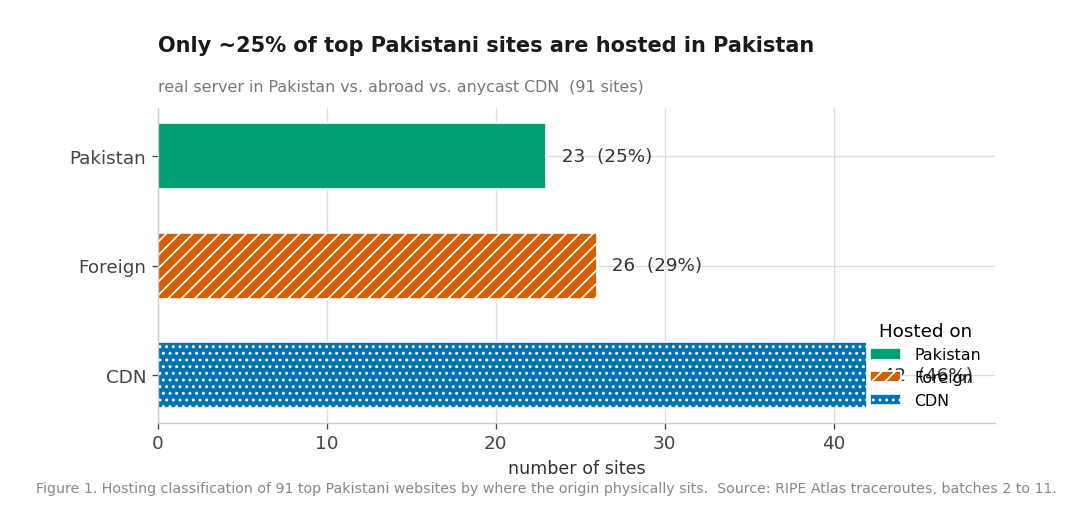

In [3]:
vals = [census[k] for k in order]
fig, ax = plt.subplots(figsize=(9, 3.4))
bars = ax.barh(order[::-1], vals[::-1], height=0.6,
               color=[cmap[k] for k in order[::-1]],
               hatch=[HATCH[k] for k in order[::-1]], edgecolor='white')
ax.bar_label(bars, labels=[f'  {v}  ({v/total:.0%})' for v in vals[::-1]],
             padding=2, fontsize=11, color='#333')
ax.set_xlim(0, max(vals) * 1.18)
style(ax, xlabel='number of sites')
ax.legend(handles=[Patch(facecolor=cmap[k], hatch=HATCH[k], edgecolor='white',
                         label=k) for k in order],
          title='Hosted on', frameon=False, loc='lower right')
titles(ax, 'Only ~25% of top Pakistani sites are hosted in Pakistan',
       'real server in Pakistan vs. abroad vs. anycast CDN  (91 sites)')
figcap(fig, 1, 'Hosting classification of 91 top Pakistani websites by where the '
               'origin physically sits.')
plt.show()

## 3. Hosting by sector

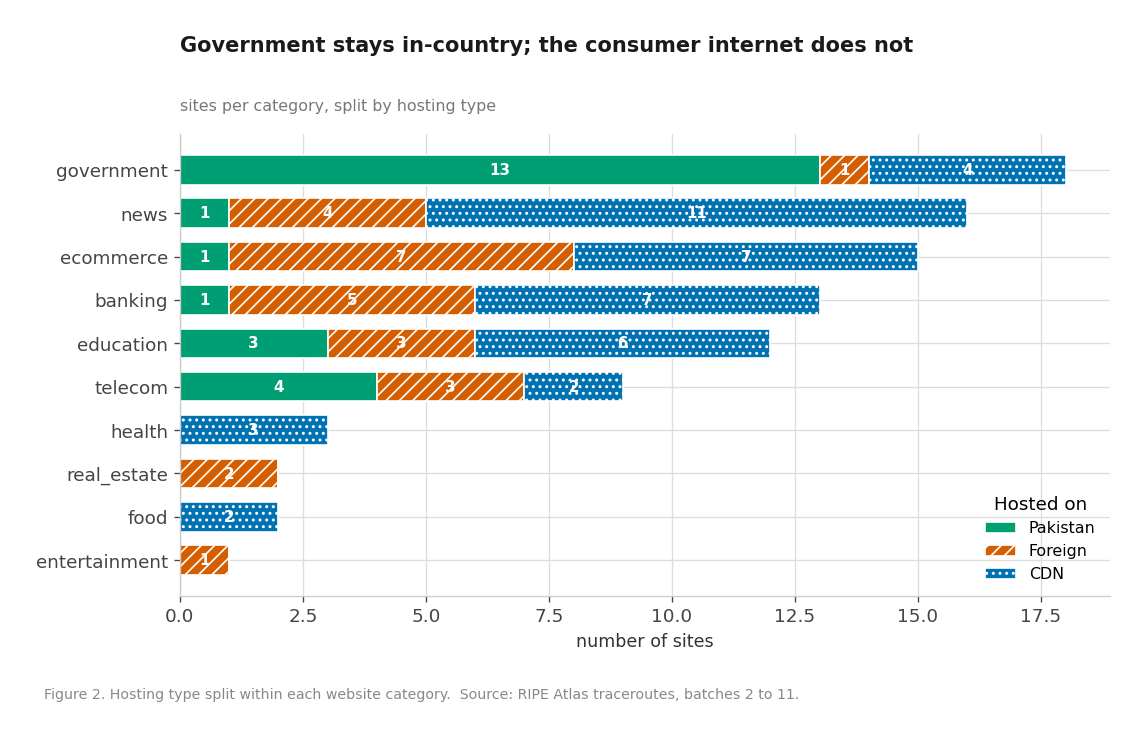

In [4]:
cats = [c for c, _ in sorted(cat_host.items(), key=lambda x: -sum(x[1].values()))]
fig, ax = plt.subplots(figsize=(10, 5))
left = np.zeros(len(cats))
for k in order:
    v = np.array([cat_host[c][k] for c in cats])
    b = ax.barh(cats, v, left=left, color=cmap[k], hatch=HATCH[k],
                edgecolor='white', label=k, height=0.68)
    ax.bar_label(b, labels=[str(x) if x else '' for x in v], label_type='center',
                 color='white', fontsize=9, fontweight='bold')
    left += v
ax.invert_yaxis()
ax.legend(title='Hosted on', loc='lower right', frameon=False)
style(ax, xlabel='number of sites')
titles(ax, 'Government stays in-country; the consumer internet does not',
       'sites per category, split by hosting type')
figcap(fig, 2, 'Hosting type split within each website category.')
plt.show()

## 4. Foreign hosting footprint

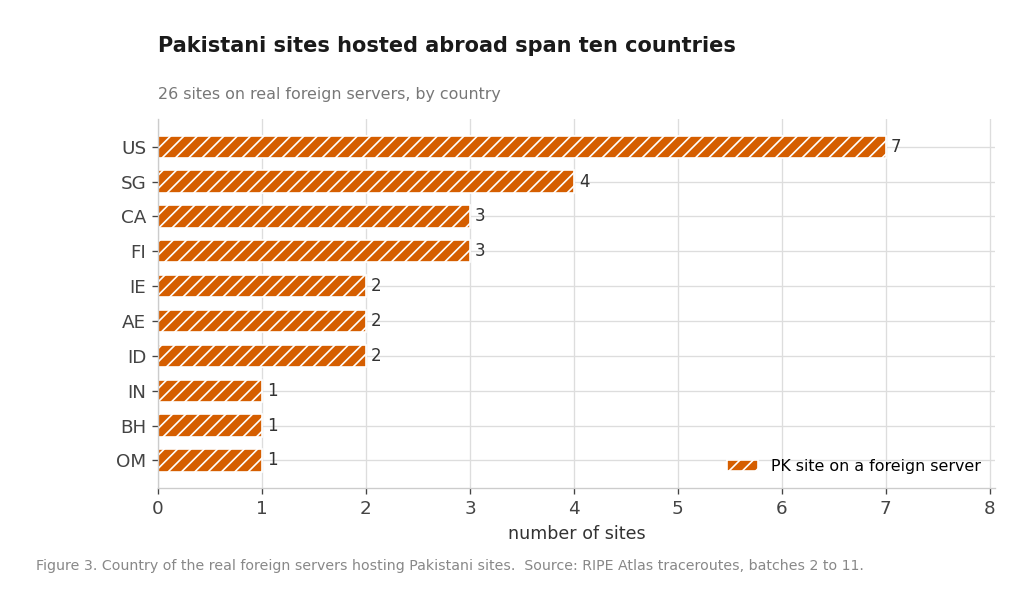

In [5]:
fc = foreign_cc.most_common()[::-1]
fig, ax = plt.subplots(figsize=(9, 4))
b = ax.barh([k for k, _ in fc], [v for _, v in fc], color=FOR, hatch='///',
            edgecolor='white', height=0.64)
ax.bar_label(b, padding=3, fontsize=10, color='#333')
ax.set_xlim(0, max(foreign_cc.values()) * 1.15)
style(ax, xlabel='number of sites')
ax.legend(handles=[Patch(facecolor=FOR, hatch='///', edgecolor='white',
                         label='PK site on a foreign server')],
          frameon=False, loc='lower right')
titles(ax, 'Pakistani sites hosted abroad span ten countries',
       '26 sites on real foreign servers, by country')
figcap(fig, 3, 'Country of the real foreign servers hosting Pakistani sites.')
plt.show()

## 5. CDN delivery: where traffic enters the CDN

> **Caveat:** entering the CDN locally is not proof the page is served locally.
> A traceroute can reach a local Cloudflare node while the HTTPS request is served
> from a distant PoP (confirmed for `shaukatkhanum.org.pk`: local ~4 ms hop, but
> `colo=SIN`). This is the network-edge view, not authoritative serving location.

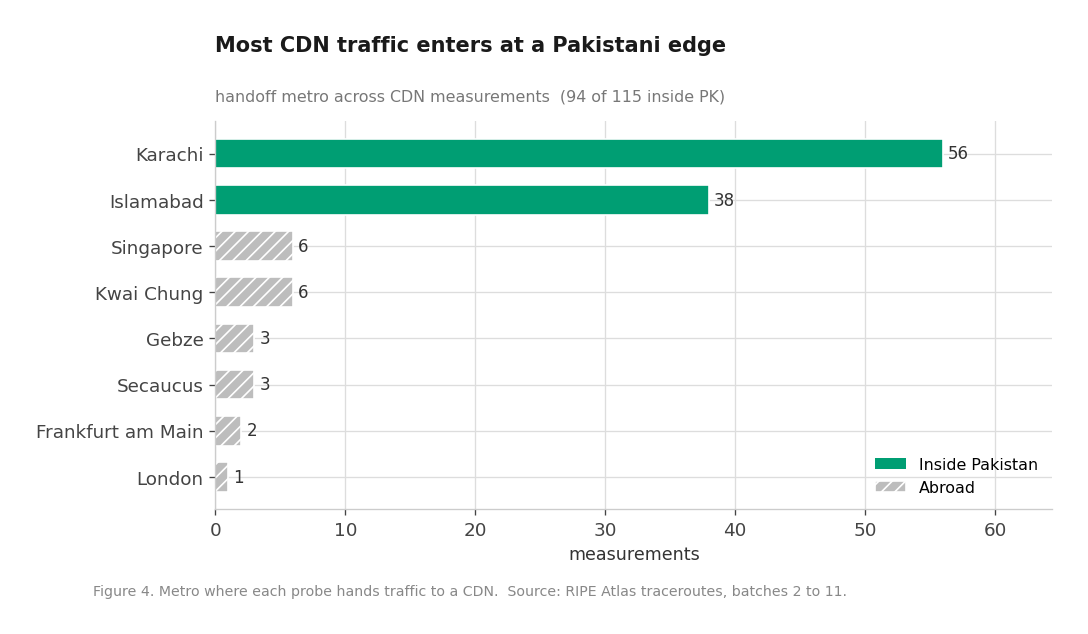

In [6]:
metro = Counter()
for r in summary:
    if r['target_asn'] in ANYCAST and r.get('dest_location'):
        metro[r['dest_location'].split(',')[0]] += 1
mm = metro.most_common(8)[::-1]
pk_metros = {'Karachi', 'Islamabad', 'Lahore'}
inside = [m in pk_metros for m, _ in mm]
cols = [PK if i else MUTED for i in inside]
hatches = ['' if i else '///' for i in inside]
fig, ax = plt.subplots(figsize=(9, 4.2))
b = ax.barh([m for m, _ in mm], [v for _, v in mm], color=cols, height=0.64,
            hatch=hatches, edgecolor='white')
ax.bar_label(b, padding=3, fontsize=10, color='#333')
local = sum(v for m, v in metro.items() if m in pk_metros)
ax.set_xlim(0, max(metro.values()) * 1.15)
style(ax, xlabel='measurements')
ax.legend(handles=[Patch(facecolor=PK, label='Inside Pakistan'),
                   Patch(facecolor=MUTED, hatch='///', edgecolor='white',
                         label='Abroad')], frameon=False, loc='lower right')
titles(ax, 'Most CDN traffic enters at a Pakistani edge',
       f'handoff metro across CDN measurements  ({local} of {sum(metro.values())} inside PK)')
figcap(fig, 4, 'Metro where each probe hands traffic to a CDN.')
plt.show()

## 6. Per-ISP routing quality

> **Caveat (selection bias):** absolute RTT comparisons are confounded because the
> *set of destinations that respond differs per probe*, and RTT is single-packet.
> Nayatel's lead is robust; PTCL's high value partly reflects that the sites it
> reaches fastest (DDoS-scrubbed gov sites at ~1 ms) do not reply and are excluded.
> Read this chart as indicative; the path-based figures (7-8) are the firm evidence.

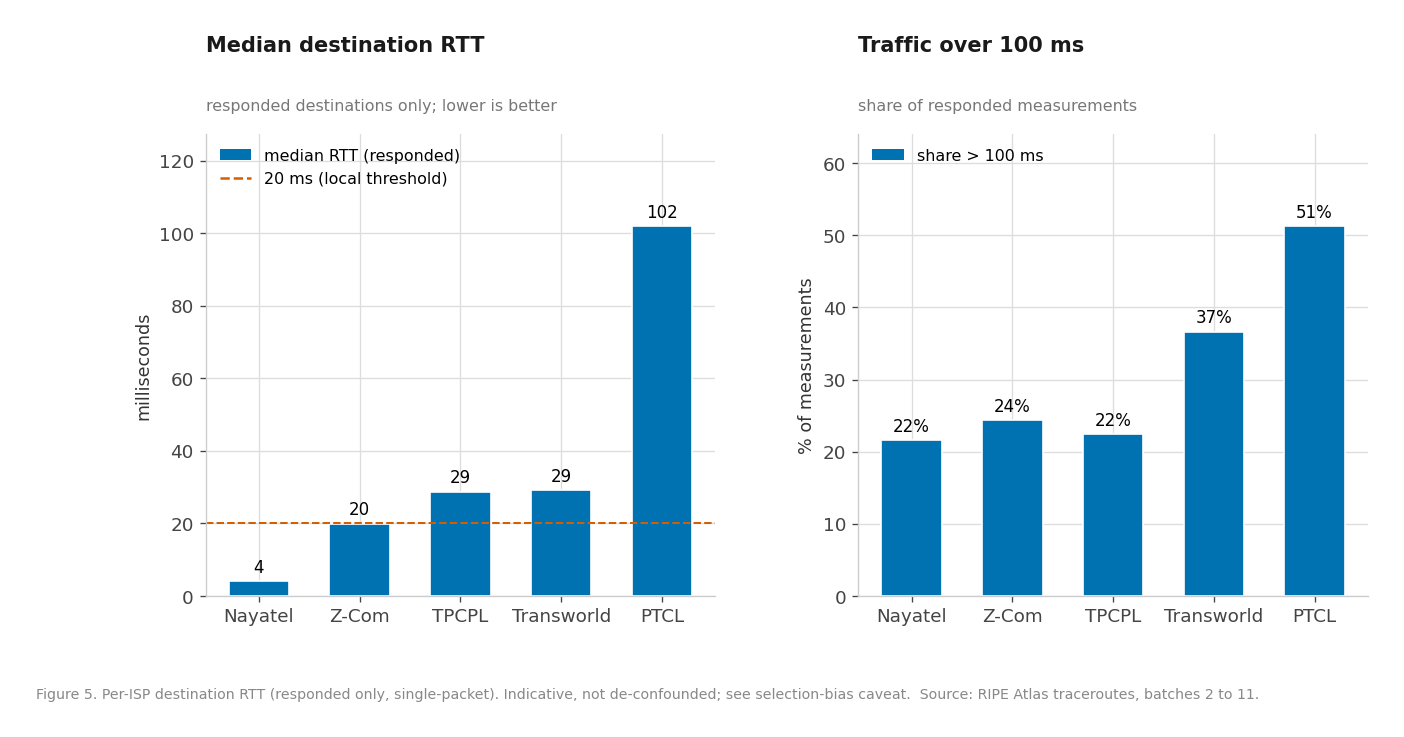

In [7]:
recs = []
for mid, hops in grouped.items():
    f = hops[0]
    if f['destination_responded'].lower() != 'true':
        continue
    dr = [float(h['rtt_ms']) for h in hops if h['hop_ip'] == f['target_ip'] and h['rtt_ms']]
    if dr:
        recs.append((f['probe_asn'], f['target_hostname'], min(dr)))

byp = defaultdict(list)
for asn, h, rtt in recs:
    byp[asn].append(rtt)
isps = sorted(byp, key=lambda a: statistics.median(byp[a]))
labels = [PN.get(a, a) for a in isps]
meds = [statistics.median(byp[a]) for a in isps]
hair = [100 * sum(1 for x in byp[a] if x > 100) / len(byp[a]) for a in isps]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
b0 = axes[0].bar(labels, meds, color=ACCENT, width=0.6, edgecolor='white')
axes[0].bar_label(b0, labels=[f'{m:.0f}' for m in meds], padding=3, fontsize=10)
axes[0].axhline(20, ls='--', lw=1.2, color=OI['vermillion'])
axes[0].set_ylim(0, max(meds) * 1.25)
style(axes[0], ylabel='milliseconds')
axes[0].legend(handles=[Patch(facecolor=ACCENT, label='median RTT (responded)'),
                        Line2D([0], [0], ls='--', color=OI['vermillion'],
                               label='20 ms (local threshold)')],
               frameon=False, loc='upper left')
titles(axes[0], 'Median destination RTT', 'responded destinations only; lower is better')
b1 = axes[1].bar(labels, hair, color=ACCENT, width=0.6, edgecolor='white')
axes[1].bar_label(b1, labels=[f'{x:.0f}%' for x in hair], padding=3, fontsize=10)
axes[1].set_ylim(0, max(hair) * 1.25)
style(axes[1], ylabel='% of measurements')
axes[1].legend(handles=[Patch(facecolor=ACCENT, label='share > 100 ms')],
               frameon=False, loc='upper left')
titles(axes[1], 'Traffic over 100 ms', 'share of responded measurements')
fig.subplots_adjust(wspace=0.28)
figcap(fig, 5, 'Per-ISP destination RTT (responded only, single-packet). Indicative, '
               'not de-confounded; see selection-bias caveat.')
plt.show()

## 7. Same site, different ISP

The same Cloudflare-fronted banking site is reached in **3 to 4 ms on Nayatel** but
**hundreds of ms on PTCL**, a large gap to identical content.

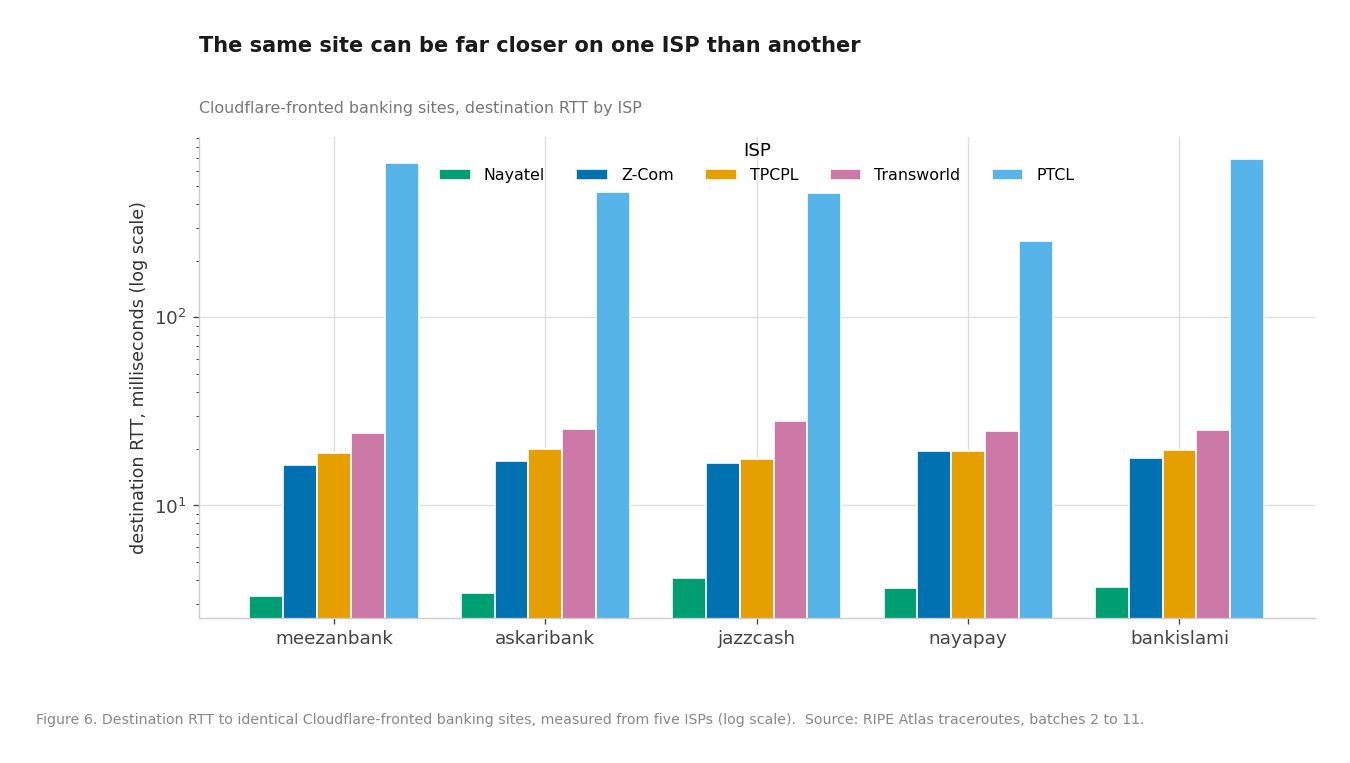

In [8]:
bysite = defaultdict(dict)
for asn, h, rtt in recs:
    bysite[h][asn] = rtt
show = [s for s in ['meezanbank.com', 'askaribank.com.pk', 'jazzcash.com.pk',
                    'nayapay.com', 'bankislami.com.pk'] if s in bysite]
isp_order = ['23674', '152605', '136174', '38193', '17557']
x = np.arange(len(show)); w = 0.16
fig, ax = plt.subplots(figsize=(12, 5.2))
for i, a in enumerate(isp_order):
    ax.bar(x + i * w, [bysite[s].get(a, 0) for s in show], w,
           label=PN.get(a, a), color=ISP5[i], edgecolor='white')
ax.set_yscale('log')
ax.set_xticks(x + 2 * w)
ax.set_xticklabels([s.replace('.com', '').replace('.pk', '') for s in show])
ax.legend(title='ISP', frameon=False, ncol=5, loc='upper center',
          bbox_to_anchor=(0.5, 1.02))
style(ax, ylabel='destination RTT, milliseconds (log scale)')
titles(ax, 'The same site can be far closer on one ISP than another',
       'Cloudflare-fronted banking sites, destination RTT by ISP')
figcap(fig, 6, 'Destination RTT to identical Cloudflare-fronted banking sites, '
               'measured from five ISPs (log scale).')
plt.show()

## 8. Transit dependency (robust, path-based)

Share of each ISP's paths that pass through an **LDI operator** (PTCL AS17557 or
Transworld AS38193). Smaller ISPs route essentially everything through the two
international-transit providers; Nayatel is largely independent. This is RTT-free
and the strongest evidence of the transit hierarchy.

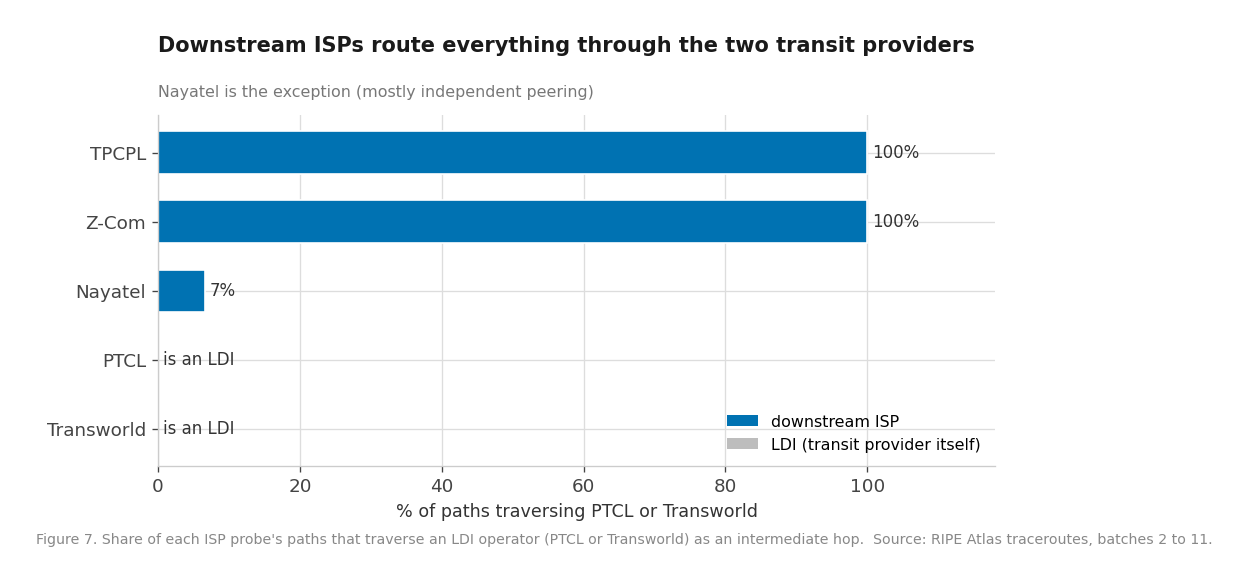

In [9]:
dep = defaultdict(lambda: [0, 0])
for mid, hops in grouped.items():
    p = hops[0]['probe_asn']; dep[p][1] += 1
    ases = {h['hop_asn'] for h in hops[1:]}          # skip the probe's own first hop
    if '17557' in ases or '38193' in ases:
        dep[p][0] += 1
ld = sorted(dep, key=lambda a: dep[a][0] / dep[a][1])
pct = [100 * dep[a][0] / dep[a][1] for a in ld]
names = [PN.get(a, a) for a in ld]
isld = [a in ('17557', '38193') for a in ld]
cols = [MUTED if x else ACCENT for x in isld]

fig, ax = plt.subplots(figsize=(9, 3.8))
b = ax.barh(names, pct, color=cols, edgecolor='white', height=0.62)
ax.bar_label(b, labels=[('is an LDI' if isld[i] else f'{pct[i]:.0f}%')
                        for i in range(len(ld))], padding=3, fontsize=10, color='#333')
ax.set_xlim(0, 118)
style(ax, xlabel='% of paths traversing PTCL or Transworld')
ax.legend(handles=[Patch(facecolor=ACCENT, label='downstream ISP'),
                   Patch(facecolor=MUTED, label='LDI (transit provider itself)')],
          frameon=False, loc='lower right')
titles(ax, 'Downstream ISPs route everything through the two transit providers',
       'Nayatel is the exception (mostly independent peering)')
figcap(fig, 7, 'Share of each ISP probe\'s paths that traverse an LDI operator '
               '(PTCL or Transworld) as an intermediate hop.')
plt.show()

## 9. Hairpinning of Pakistan-hosted sites

For sites hosted on a **real Pakistani server**, does the path leave the country?
Mostly not, but a **specific handful** do, and only for the downstream ISPs.
PTCL and Transworld reach them domestically; Nayatel, Z-Com and TPCPL send them
abroad (US DDoS-scrubbing for the gov sites, US Cogent for `pitc`). The Shaw/Canada
artifact is excluded.

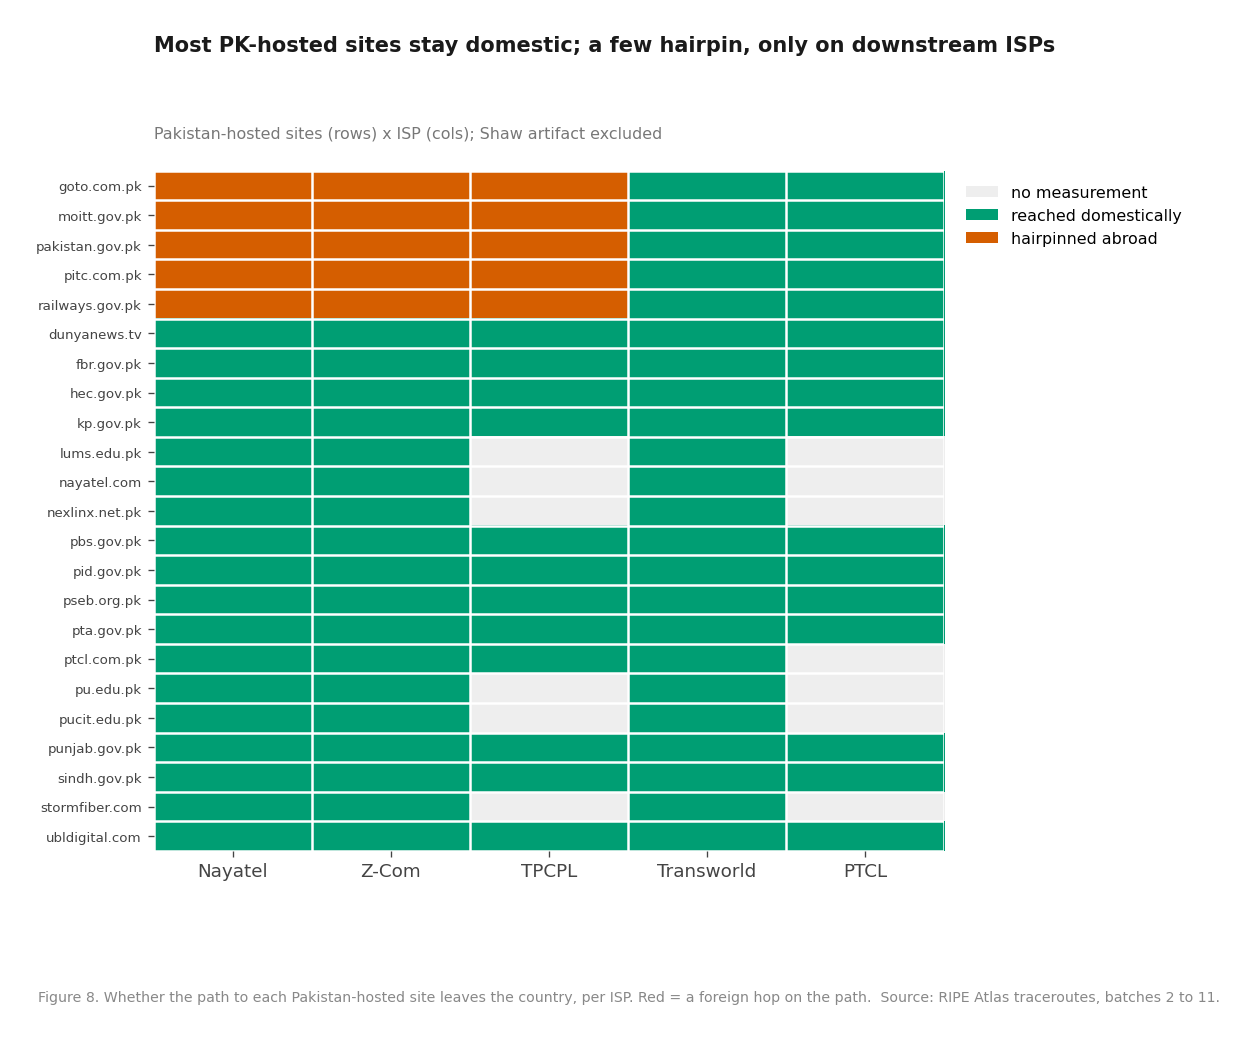

In [10]:
pk_sites = [h for h, c in site_cls.items() if c == 'Pakistan']
isp_ids = ['23674', '152605', '136174', '38193', '17557']
status = {}   # (site, asn) -> 0 none / 1 domestic / 2 hairpin
for mid, hops in grouped.items():
    f = hops[0]; s = f['target_hostname']; a = f['probe_asn']
    if site_cls.get(s) != 'Pakistan':
        continue
    foreign = any(h['hop_country'] and h['hop_country'] != 'PK'
                  and h['hop_asn'] != SHAW and h['is_private'].lower() != 'true'
                  for h in hops)
    status[(s, a)] = 2 if foreign else 1

# sort: sites that hairpin anywhere first
def nhair(s): return sum(status.get((s, a), 0) == 2 for a in isp_ids)
pk_sites = sorted(pk_sites, key=lambda s: (-nhair(s), s))
grid = np.array([[status.get((s, a), 0) for a in isp_ids] for s in pk_sites])

fig, ax = plt.subplots(figsize=(8.5, max(4, 0.32 * len(pk_sites))))
cmapM = ListedColormap(['#eeeeee', OI['green'], OI['vermillion']])
ax.imshow(grid, cmap=cmapM, norm=BoundaryNorm([0, 1, 2, 3], cmapM.N), aspect='auto')
ax.set_xticks(range(len(isp_ids))); ax.set_xticklabels([PN[a] for a in isp_ids])
ax.set_yticks(range(len(pk_sites))); ax.set_yticklabels(pk_sites, fontsize=8)
ax.set_xticks(np.arange(-.5, len(isp_ids), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(pk_sites), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5); ax.tick_params(which='minor', length=0)
ax.grid(which='major', visible=False)
for sp in ax.spines.values(): sp.set_visible(False)
ax.legend(handles=[Patch(facecolor='#eeeeee', label='no measurement'),
                   Patch(facecolor=OI['green'], label='reached domestically'),
                   Patch(facecolor=OI['vermillion'], label='hairpinned abroad')],
          frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1))
titles(ax, 'Most PK-hosted sites stay domestic; a few hairpin, only on downstream ISPs',
       'Pakistan-hosted sites (rows) x ISP (cols); Shaw artifact excluded')
figcap(fig, 8, 'Whether the path to each Pakistan-hosted site leaves the country, '
               'per ISP. Red = a foreign hop on the path.')
plt.show()

## 10. Key takeaways

1. **About 75% of top Pakistani sites are not hosted in Pakistan**, mostly Cloudflare,
   plus foreign clouds across 10 countries.
2. **Government keeps data in-country; the consumer internet does not.** News,
   banking and e-commerce are overwhelmingly offshore.
3. **The transit hierarchy is stark:** downstream ISPs (Z-Com, TPCPL) route ~100% of
   paths through PTCL or Transworld; Nayatel is largely independent.
4. **Hairpinning is concentrated, not pervasive:** a few Pakistan-hosted sites leave
   the country, and only for the downstream ISPs, while PTCL/Transworld reach them
   domestically. Direct evidence that local exchange is not happening uniformly.

*Re-run all cells after new measurement batches to refresh every figure.*